## Install YOLO11 and Necessary Libraries


In [11]:
%pip install "ultralytics<=8.3.40" supervision roboflow
!pip install bm3d
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/235.7 GB disk)


In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Fine-tune YOLO11 on custom dataset

In [2]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("cingoz8").project("kidney-stone-ultrasound-ecckd-eqfcc")
version = project.version(3)
dataset = version.download("yolov11")


mkdir: cannot create directory ‘{HOME}/datasets’: No such file or directory
[Errno 2] No such file or directory: '{HOME}/datasets'
/content
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to kidney-stone-ultrasound-3 in yolov11:: 100%|██████████| 22322/22322 [00:06<00:00, 3454.62it/s]


## Image Processing

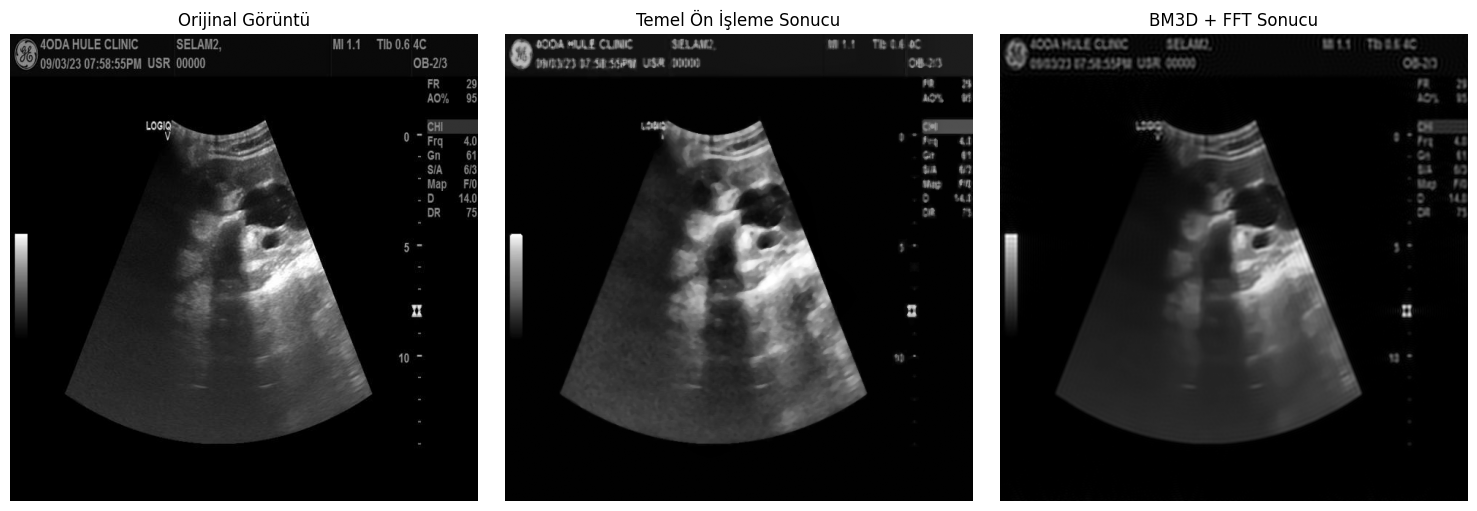

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from bm3d import bm3d
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter

def basic_preprocess_image(image_path):
    # Görüntüyü gri tonlamada oku
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Median blur ile gürültü azaltma
    median = cv2.medianBlur(img, 5)
    # CLAHE ile kontrast artırma
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    processed_img = clahe.apply(median)
    return processed_img

def advanced_preprocess_image(image_path):
    """
    Verilen ultrason görüntüsü yolundaki resmi okur,
    BM3D denoising uygular ve ardından basitleştirilmiş brushlet thresholding
    (FFT low-pass filtering) ile gürültü azaltımı yapar.
    """
    # Görüntüyü gri tonlamalı olarak yükle ve [0,1] aralığına normalize et.
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Görüntü yüklenemedi, lütfen geçerli bir yol sağlayın.")
    img = img.astype(np.float32) / 255.0

    # BM3D denoising uygulaması (sigma_psd değeri deneysel olarak belirlenmelidir)
    denoised = bm3d(img, sigma_psd=0.1)

    # Brushlet thresholding benzeri bir işlem için:
    # 2D Fourier dönüşümü, merkezi düşük frekansları korumak üzere maskeleme ve ters Fourier dönüşümü
    f = np.fft.fft2(denoised)
    fshift = np.fft.fftshift(f)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    # Maske: merkezi düşük frekans bileşenlerini korumak için dairesel bir maske oluşturuyoruz.
    radius = int(0.3 * min(crow, ccol))
    y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    mask = x*x + y*y <= radius*radius

    # Yüksek frekans bileşenlerini sıfırlayarak filtre uygula
    fshift_filtered = fshift * mask

    # Ters Fourier dönüşümü ile uzay alanına dön
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_filtered = np.fft.ifft2(f_ishift)
    img_filtered = np.abs(img_filtered)

    # Sonucu 0-255 aralığına normalize et ve uint8 formatına çevir
    img_filtered = cv2.normalize(img_filtered, None, 0, 255, cv2.NORM_MINMAX)
    img_filtered = img_filtered.astype(np.uint8)

    return img_filtered


def gpu_preprocess_image_alternative(image_path):
    """
    GPU üzerinde Cupy kullanarak ultrason görüntüsünü işler:
    - Gaussian filtresi ile denoising (BM3D yerine örnek amaçlı)
    - Cupy ile FFT low-pass filtering (brushlet thresholding benzeri)
    """
    # Görüntüyü gri tonlamalı olarak yükle ve [0,1] aralığına normalize et.
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Görüntü yüklenemedi, lütfen geçerli bir yol sağlayın.")
    img = img.astype(cp.float32) / 255.0
    # Cupy dizisine aktar
    img_gpu = cp.asarray(img)

    # GPU destekli Gaussian denoising (sigma değeri örnek, deneysel olarak ayarlanmalı)
    denoised_gpu = gaussian_filter(img_gpu, sigma=1.0)

    # GPU FFT işlemleri: 2D Fourier dönüşümü
    f = cp.fft.fft2(denoised_gpu)
    fshift = cp.fft.fftshift(f)

    rows, cols = denoised_gpu.shape
    crow, ccol = rows // 2, cols // 2
    # Merkezi düşük frekansları korumak için dairesel maske oluşturuyoruz
    radius = int(0.3 * min(crow, ccol))
    y, x = cp.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    mask = (x**2 + y**2) <= (radius**2)

    # Maske uygulaması
    fshift_filtered = fshift * mask

    # Ters FFT dönüşümü
    f_ishift = cp.fft.ifftshift(fshift_filtered)
    img_filtered_gpu = cp.fft.ifft2(f_ishift)
    img_filtered = cp.abs(img_filtered_gpu)

    # Sonucu CPU'ya aktar
    img_filtered = cp.asnumpy(img_filtered)

    # Sonucu 0-255 aralığına normalize et ve uint8 formatına çevir
    img_filtered = cv2.normalize(img_filtered, None, 0, 255, cv2.NORM_MINMAX)
    img_filtered = img_filtered.astype('uint8')

    return img_filtered
# Örnek kullanım
image_path = "/content/kidney-stone-ultrasound-3/test/images/0001-N39JTOG4_jpg.rf.ef447cf368c263699342ed384b2e76ee.jpg"  # test edilecek örnek dosya yolu
#processed_img = basic_preprocess_image(image_path)

#processed_img = gpu_preprocess_image_alternative(image_path)
basic_processed_img = basic_preprocess_image(image_path)
# Load the original image
original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Gelişmiş işlenmiş görseli oluştur
advanced_processed_img = advanced_preprocess_image(image_path)


# 3 subplot oluştur
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Her bir görseli ve başlığını ayarla
ax1.imshow(original_img, cmap='gray')
ax1.set_title("Orijinal Görüntü")
ax1.axis("off")

ax2.imshow(basic_processed_img, cmap='gray')
ax2.set_title("Temel Ön İşleme Sonucu")
ax2.axis("off")

ax3.imshow(advanced_processed_img, cmap='gray')
ax3.set_title("BM3D + FFT Sonucu")
ax3.axis("off")

# Grafiği göster
plt.tight_layout()
plt.show()


In [ ]:
import cv2
import os
import glob
from tqdm import tqdm

def basic_preprocess_image(image_path):
    # Görüntüyü gri tonlamada oku
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Median blur ile gürültü azaltma
    median = cv2.medianBlur(img, 5)
    # CLAHE ile kontrast artırma
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    processed_img = clahe.apply(median)
    return processed_img

# Veri dizinlerinin bulunduğu ana dizin
base_dir = "/content/kidney-stone-ultrasound-3"
subdirs = ["test", "train", "valid"]

for subdir in subdirs:
    # Orijinal görüntülerin olduğu dizin
    src_dir = os.path.join(base_dir, subdir, "images")
    # İşlenmiş görüntülerin kaydedileceği dizin
    dest_dir = os.path.join(base_dir, subdir, "processed_images")
    os.makedirs(dest_dir, exist_ok=True)

    # jpg uzantılı dosyaları alıyoruz, gerekirse png vb. uzantıları da ekleyebilirsiniz
    image_files = glob.glob(os.path.join(src_dir, '*.jpg'))
    image_files.extend(glob.glob(os.path.join(src_dir, '*.png')))

    # Her bir görüntüyü işleyip kaydediyoruz
    for img_path in tqdm(image_files, desc=f"Processing {subdir} images"):
        processed = gpu_preprocess_image_alternative(img_path)
        # Orijinal dosya adını koruyarak kaydet
        filename = os.path.basename(img_path)
        dest_path = os.path.join(dest_dir, filename)
        cv2.imwrite(dest_path, processed)

print("Tüm görüntüler başarıyla işlendi ve kaydedildi.")


Processing valid images: 100%|██████████| 544/544 [00:02<00:00, 187.05it/s]

Tüm görüntüler başarıyla işlendi ve kaydedildi.


## Custom Training

In [18]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11m.pt data={dataset.location}/data.yaml epochs=60 imgsz=640 batch=24 plots=True

# prompt: download runs directory to my local

import os
from google.colab import files

# Define the source directory
source_dir = "/content/runs"  # Replace with your actual runs directory

# Create a zip file of the directory
!zip -r /content/runs.zip {source_dir}

# Download the zip file
files.download("/content/runs.zip")


[Errno 2] No such file or directory: '{HOME}'
/content
New https://pypi.org/project/ultralytics/8.3.102 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=/content/kidney-stone-ultrasound-3/data.yaml, epochs=60, time=None, patience=100, batch=24, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [22]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!yolo task=detect mode=train model=yolo11m.pt data=/content/kidney-stone-ultrasound-3/data.yaml epochs=20 imgsz=640 batch=24 plots=True

New https://pypi.org/project/ultralytics/8.3.102 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=/content/kidney-stone-ultrasound-3/data.yaml, epochs=20, time=None, patience=100, batch=24, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show

In [ ]:
# prompt: download runs directory to my local

import os
from google.colab import files

# Define the source directory
source_dir = "/content/runs"  # Replace with your actual runs directory

# Create a zip file of the directory
!zip -r /content/runs.zip {source_dir}

# Download the zip file
files.download("/content/runs.zip")


  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/args.yaml (deflated 53%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/events.out.tfevents.1743073338.a13f1bfdc0a7.3468.0 (deflated 9%)
  adding: content/runs/detect/train5/ (stored 0%)
  adding: content/runs/detect/train5/PR_curve.png (deflated 12%)
  adding: content/runs/detect/train5/val_batch2_pred.jpg (deflated 16%)
  adding: content/runs/detect/train5/val_batch2_labels.jpg (deflated 18%)
  adding: content/runs/detect/train5/train_batch4202.jpg (deflated 17%)
  adding: content/runs/detect/train5/args.yaml (deflated 53%)
  adding: content/runs/detect/train5/train_batch0.jpg (deflated 14%)
  adding: content/runs/detect/train5/weights/ (stored 0%)
  adding: content/runs/detect/train5/weights/last.pt (deflated 8%)
  adding: content/runs/detect/train5/weights/best.pt (deflated 8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls {HOME}/runs/detect/train/

ls: cannot access '{HOME}/runs/detect/train/': No such file or directory


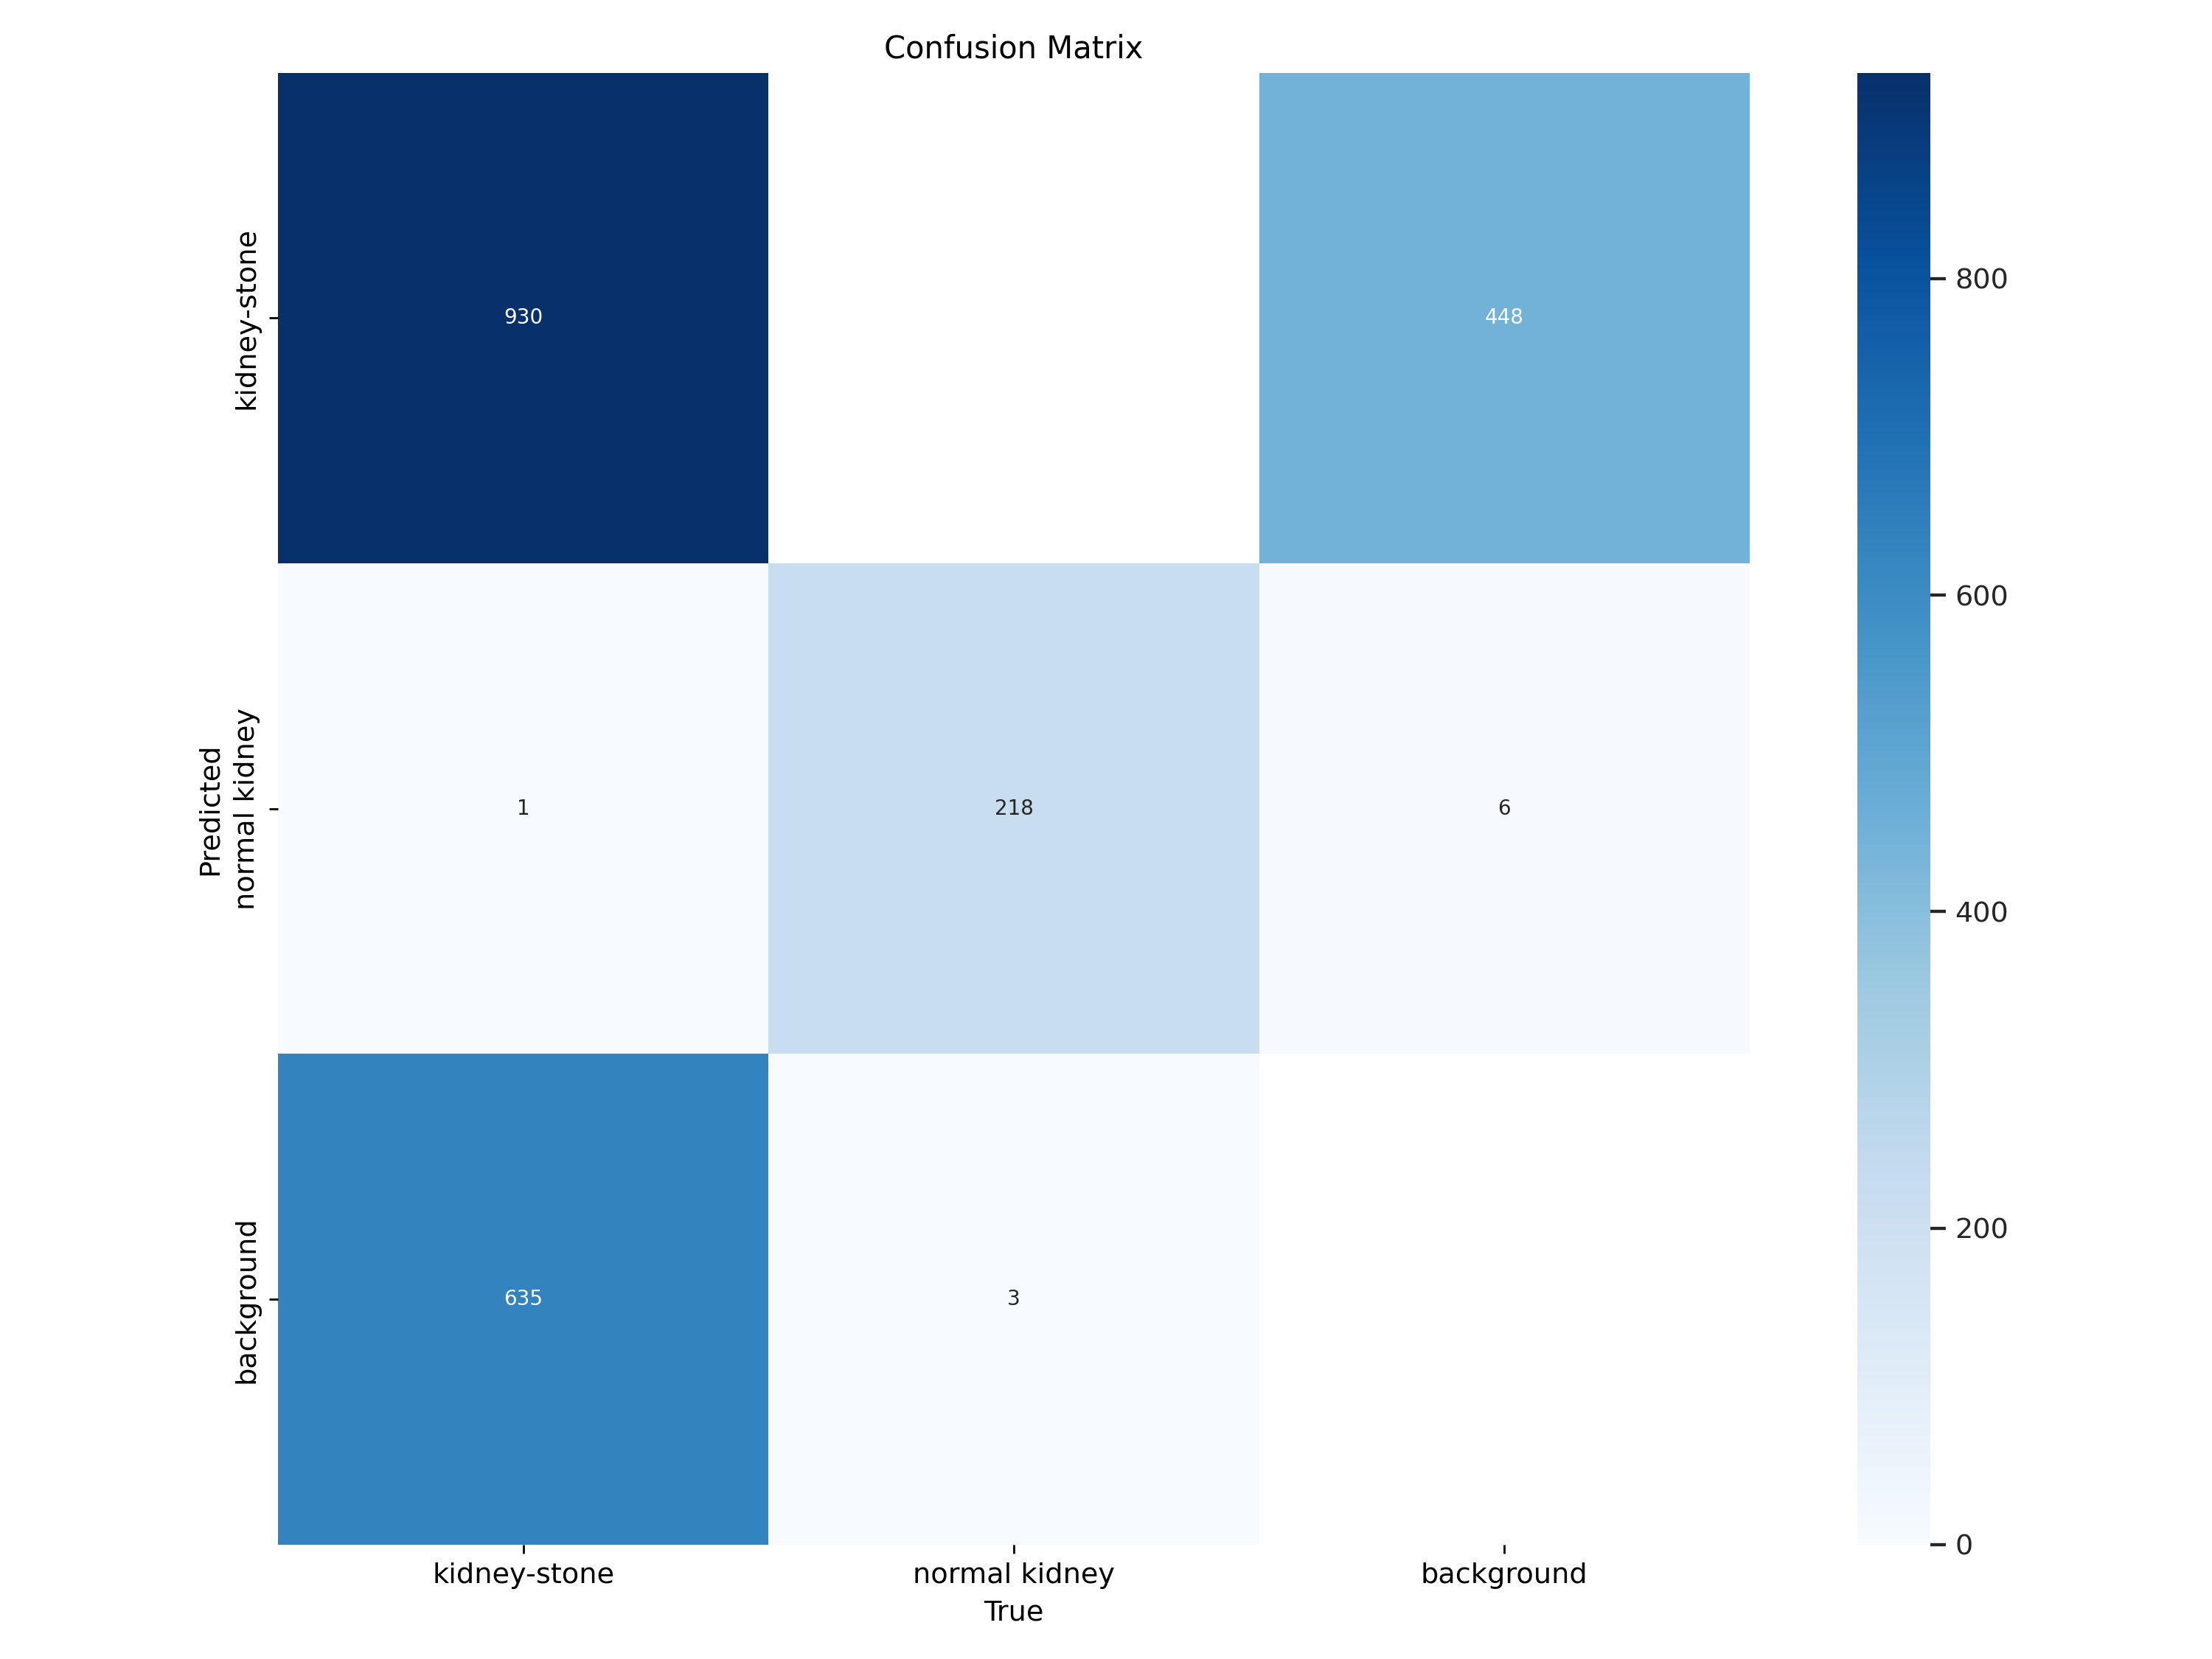

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

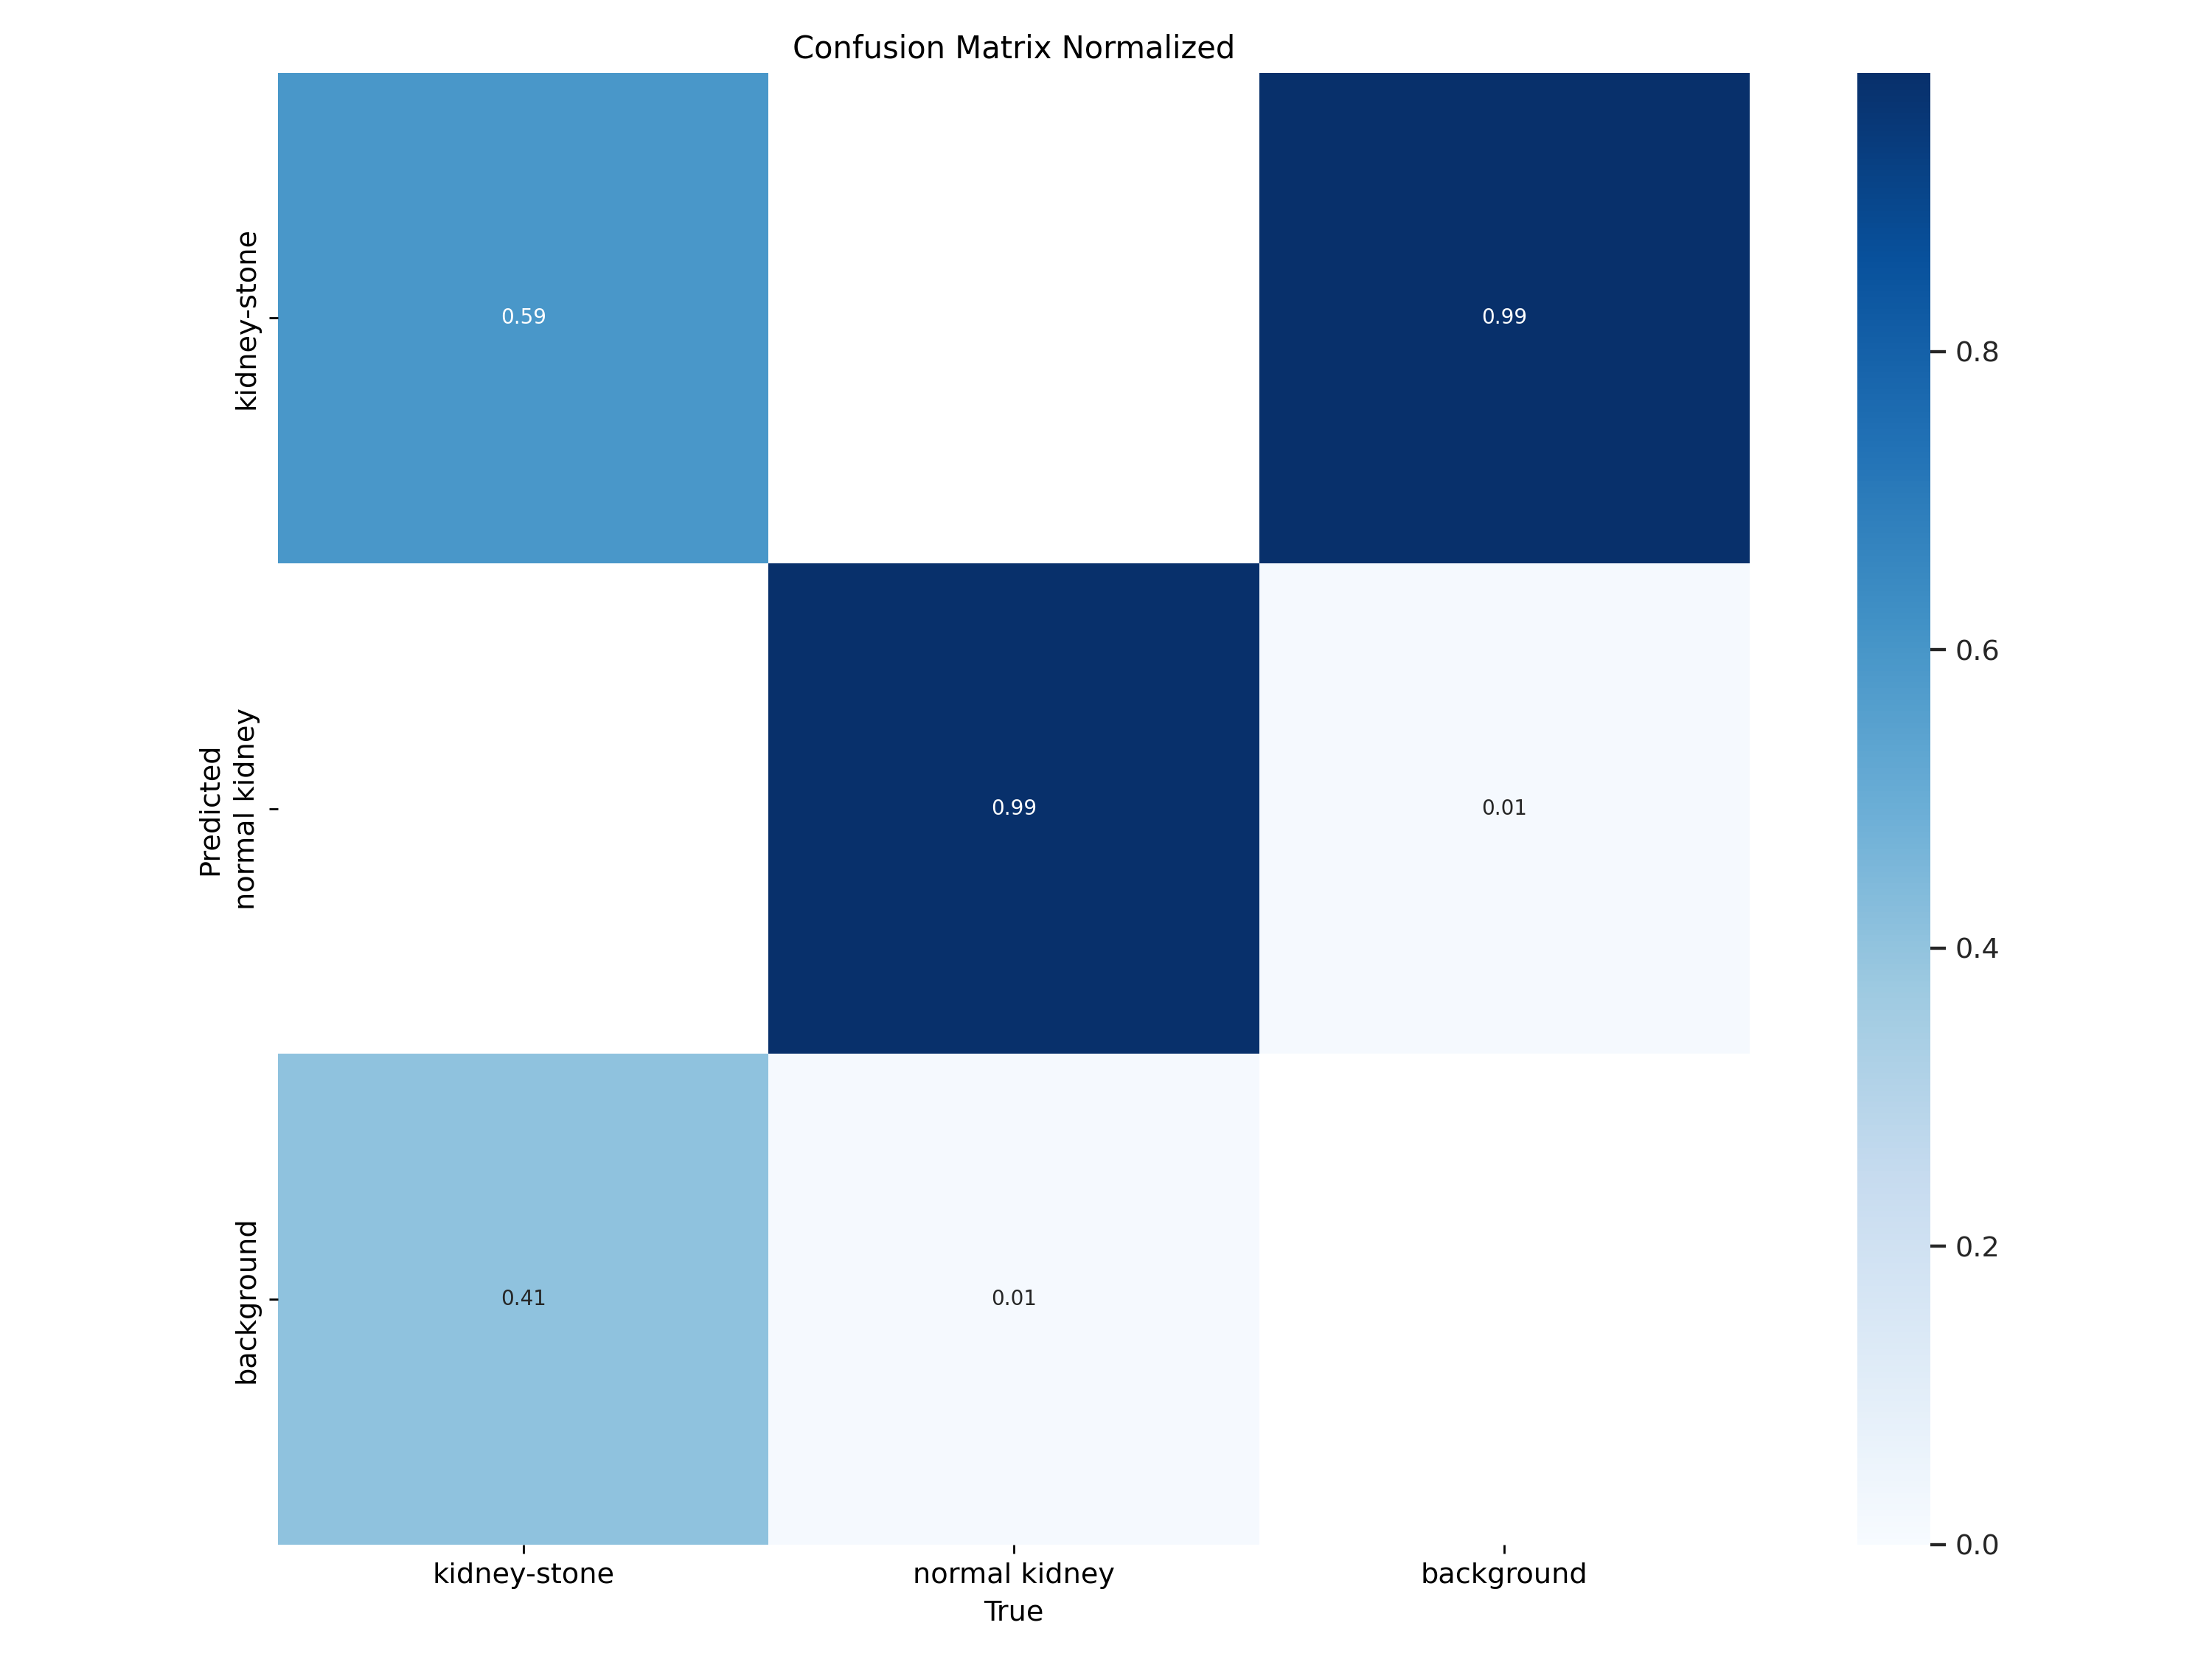

In [ ]:
# show normalized confussion matrix
IPyImage(filename=f'/content/runs/detect/train/confusion_matrix_normalized.png', width=600)

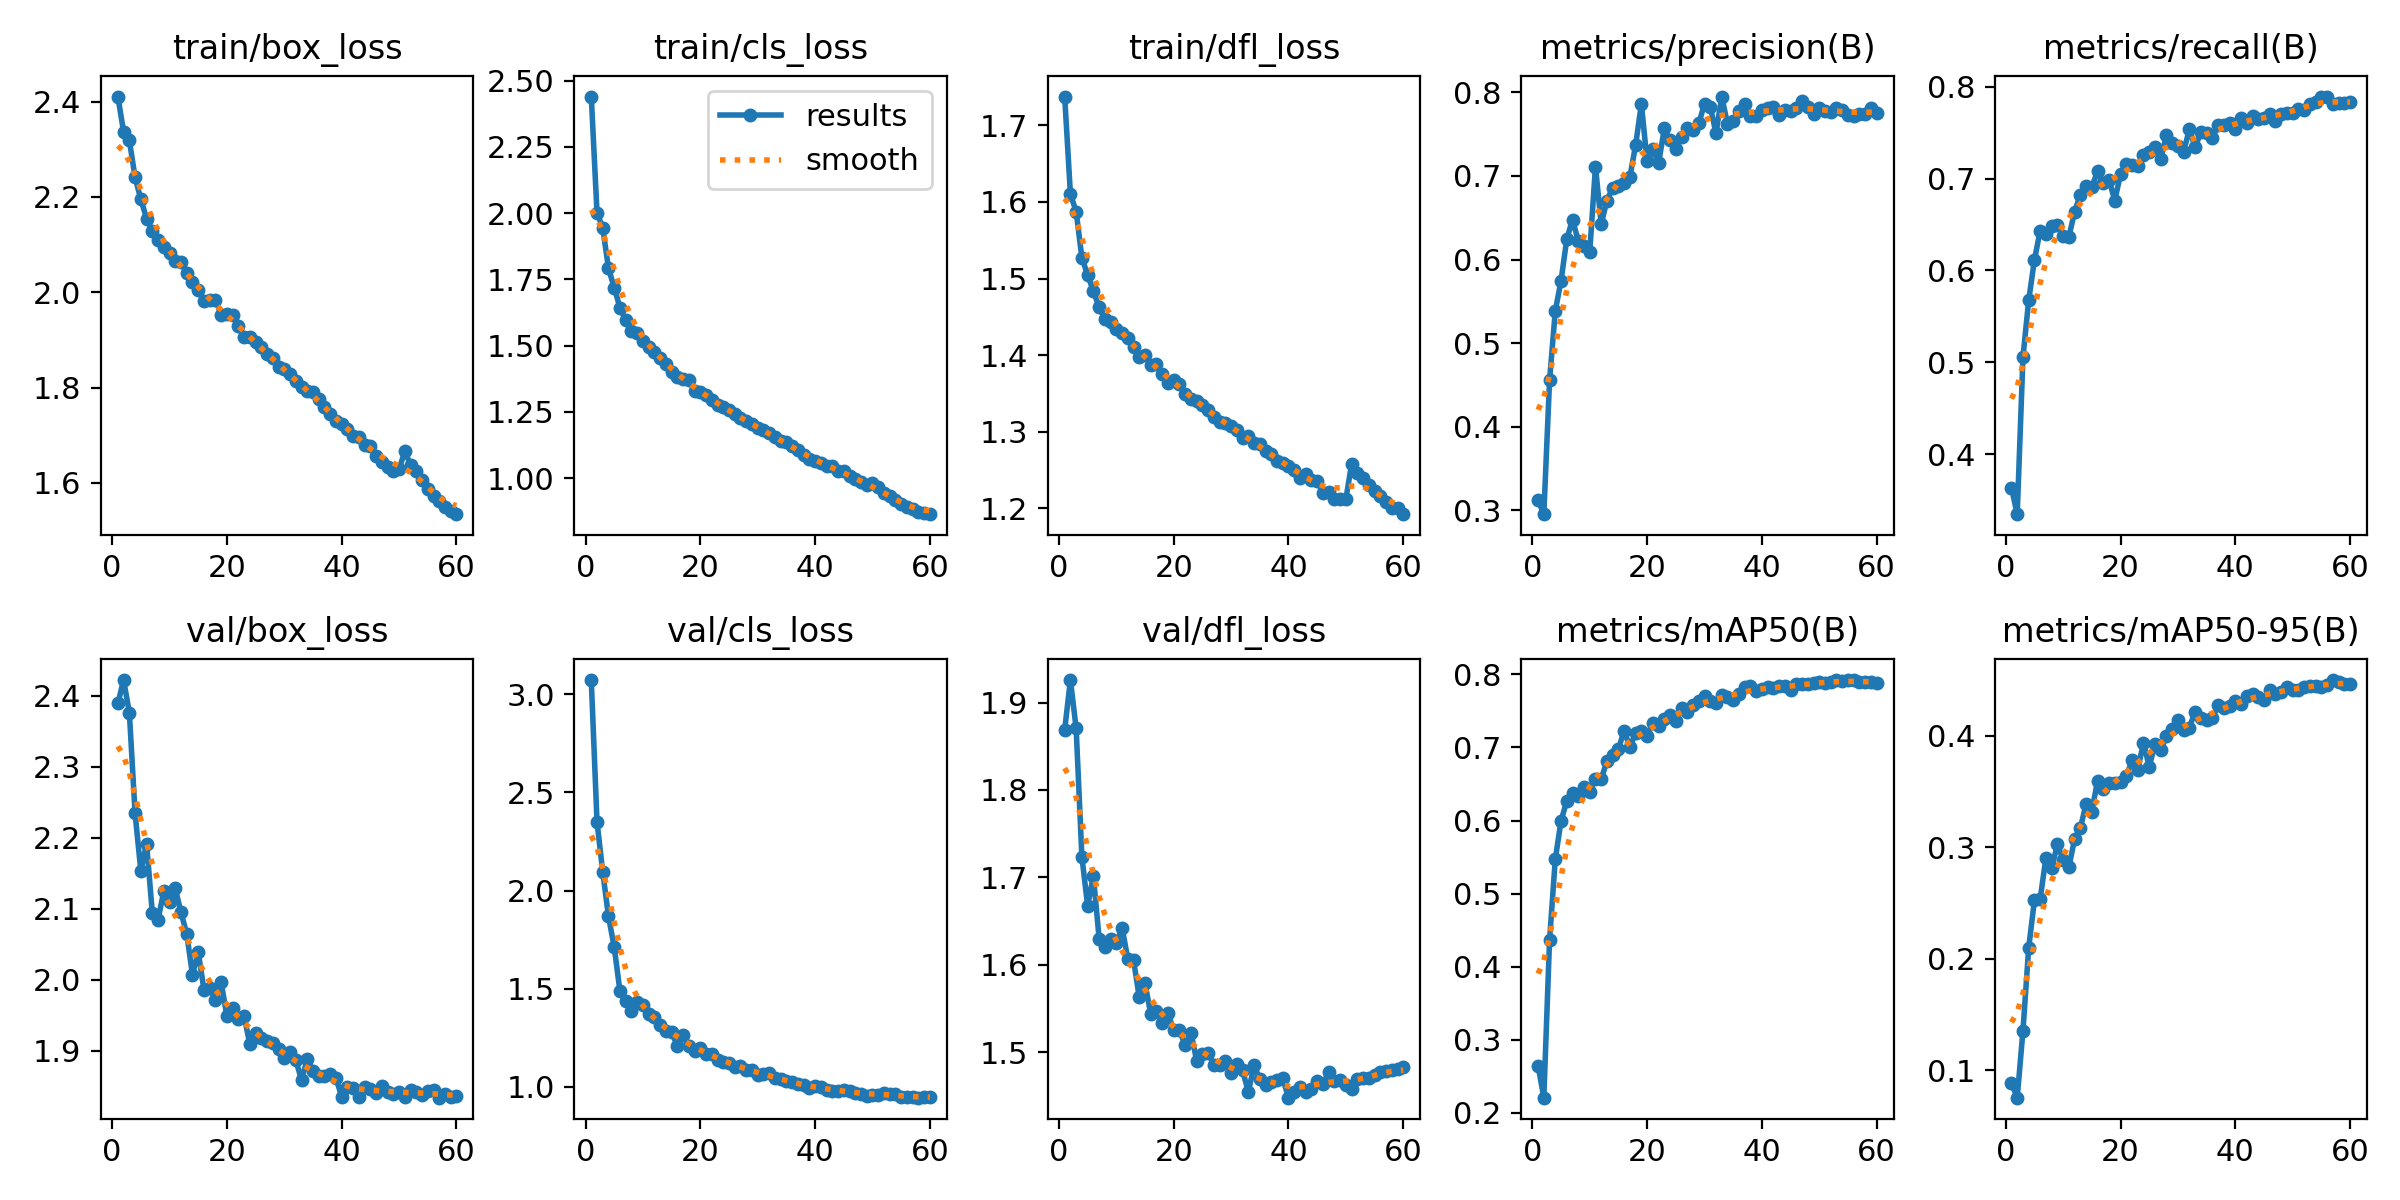

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/results.png', width=600)

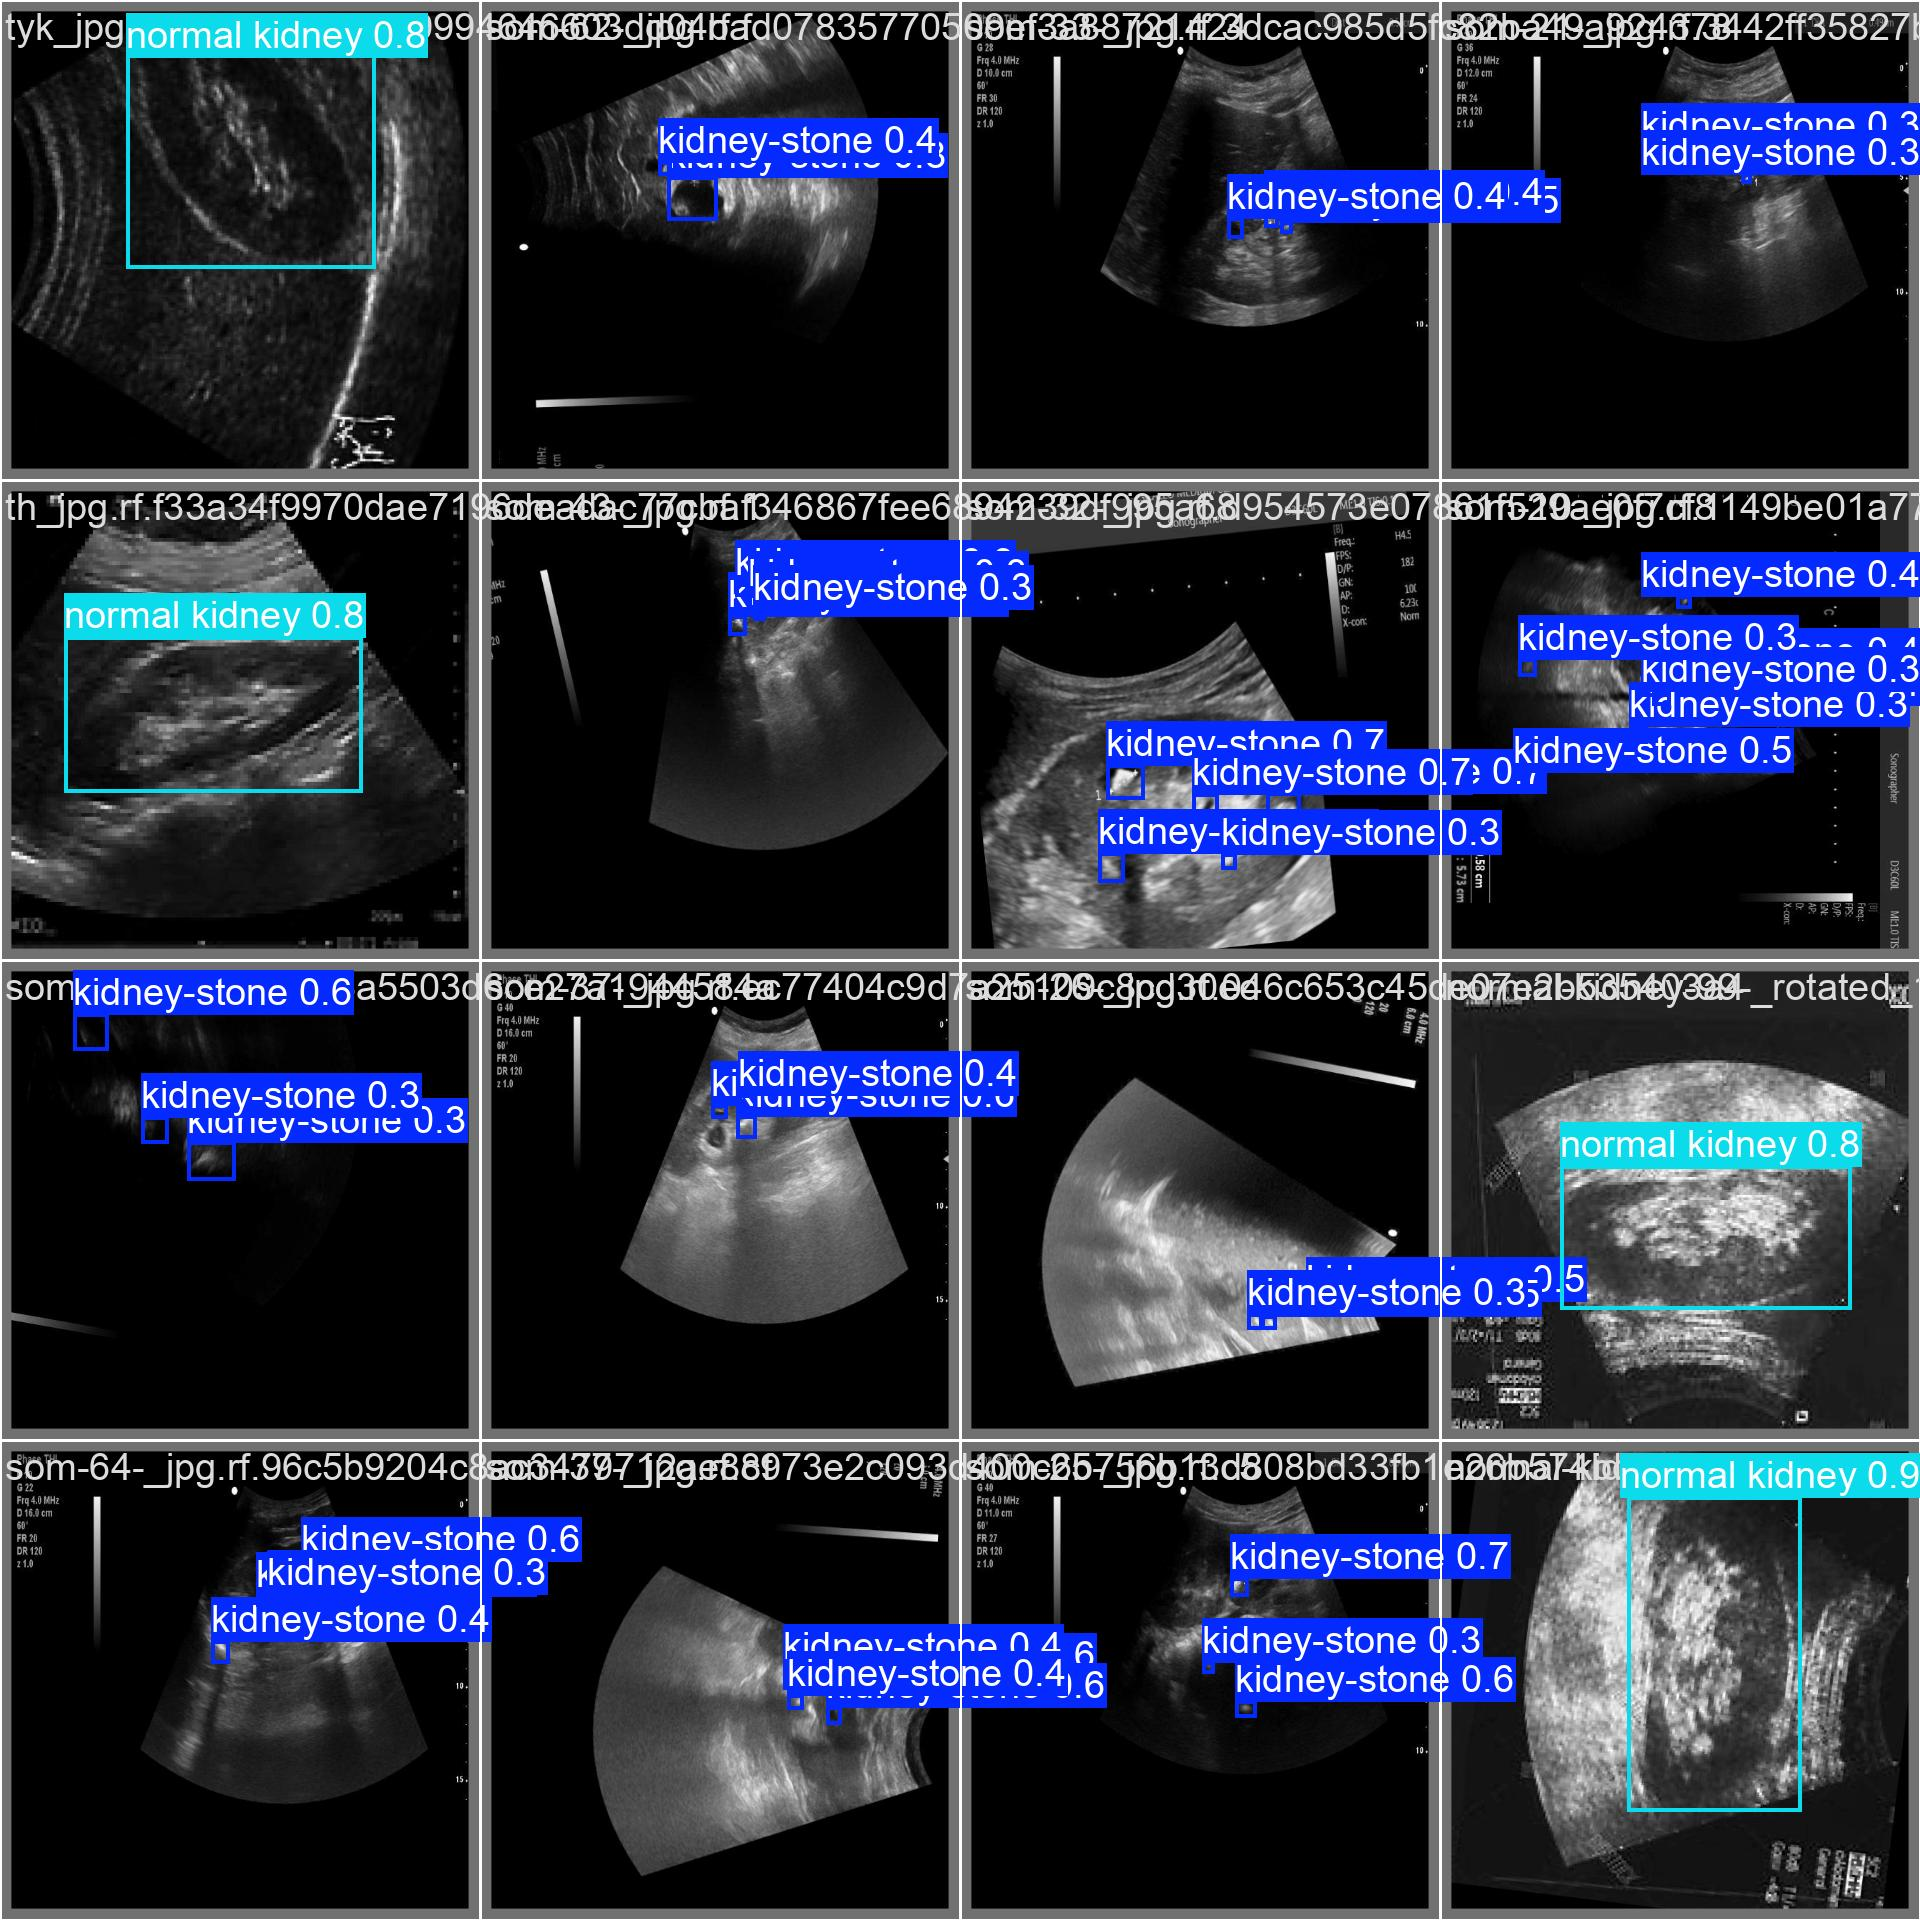

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/content/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [19]:

!yolo task=detect mode=val model=/content/drive/MyDrive/443_modeller/yolov11m/best.pt data=/content/kidney-stone-ultrasound-3/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 303 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Scanning /content/kidney-stone-ultrasound-3/valid/labels.cache... 544 images, 6 backgrounds, 0 corrupt: 100% 544/544 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 1787. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 34/34 [00:15<00:00,  2.22it/s]
                   all        544       1787      0.775       0.78      0.789       0.45
          kidney-stone        317       1566      0.627      0.583      0.598      0.243
         normal kidney        221        221      0.922      0.977      0.979      0.657
Speed: 0.4ms preprocess, 22.7m

In [ ]:
# prompt: find average inference time

import re

# Find all lines containing inference time information
with open('/content/runs/detect/train/results.txt', 'r') as f:
    lines = f.readlines()

inference_times = []
for line in lines:
    match = re.search(r"Speed: \S+ ms", line)
    if match:
        time_str = match.group(0).split(": ")[1].rstrip(" ms")
        try:
            inference_times.append(float(time_str))
        except ValueError:
            print(f"Skipping invalid time string: {time_str}")

if inference_times:
    avg_inference_time = sum(inference_times) / len(inference_times)
    print(f"Average inference time: {avg_inference_time:.2f} ms")
else:
    print("No inference time data found in results.txt")



image 1/1 /content/kidney-stone-ultrasound-3/test/images/normal-kidney-103-_rotated_45_jpg.rf.77c61e00cf513dbe1eb27f2bb03cf233.jpg: 640x640 1 normal kidney, 36.9ms
Speed: 2.3ms preprocess, 36.9ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Inference time for /content/kidney-stone-ultrasound-3/test/images/normal-kidney-103-_rotated_45_jpg.rf.77c61e00cf513dbe1eb27f2bb03cf233.jpg: 0.3976 seconds

image 1/1 /content/kidney-stone-ultrasound-3/test/images/0002-N6FCLG0C_jpg.rf.63289354a04506b4823812be5c9dc5d3.jpg: 640x640 1 normal kidney, 36.9ms
Speed: 2.0ms preprocess, 36.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Inference time for /content/kidney-stone-ultrasound-3/test/images/0002-N6FCLG0C_jpg.rf.63289354a04506b4823812be5c9dc5d3.jpg: 0.0459 seconds

image 1/1 /content/kidney-stone-ultrasound-3/test/images/kidimg-4406-_jpg.rf.c89960948a98e587c0c4cf76881a557c.jpg: 640x640 9 kidney-stones, 36.9ms
Speed: 1.8ms preprocess, 36.9ms inference, 1.6ms

## Inference with custom model

In [23]:
!yolo task=detect mode=predict model=/content/drive/MyDrive/443_modeller/yolov11m/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 303 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs

image 1/542 /content/kidney-stone-ultrasound-3/test/images/0001-N39JTOG4_jpg.rf.ef447cf368c263699342ed384b2e76ee.jpg: 640x640 5 kidney-stones, 36.7ms
image 2/542 /content/kidney-stone-ultrasound-3/test/images/0001-N39K2106_jpg.rf.e326fb665200ed2544e81113390bb7e5.jpg: 640x640 3 kidney-stones, 36.8ms
image 3/542 /content/kidney-stone-ultrasound-3/test/images/0001-N3AGL1G2_jpg.rf.3375b007e2d93054fb80f197a80b16ed.jpg: 640x640 1 kidney-stone, 36.7ms
image 4/542 /content/kidney-stone-ultrasound-3/test/images/0001-N3AGS488_jpg.rf.e80590ee3aaa6d0c4dcdca568126fde8.jpg: 640x640 4 kidney-stones, 36.8ms
image 5/542 /content/kidney-stone-ultrasound-3/test/images/0001-N3DD6LO0_jpg.rf.c54176ca16c0b182378987c3d8c4c38d.jpg: 640x640 2 kidney-stones, 36.7ms
image 6/542 /content/kidney-stone-ultrasound-3/test/images/0001-N3FCJHG0_jpg.rf.159

**NOTE:** Let's take a look at few results.

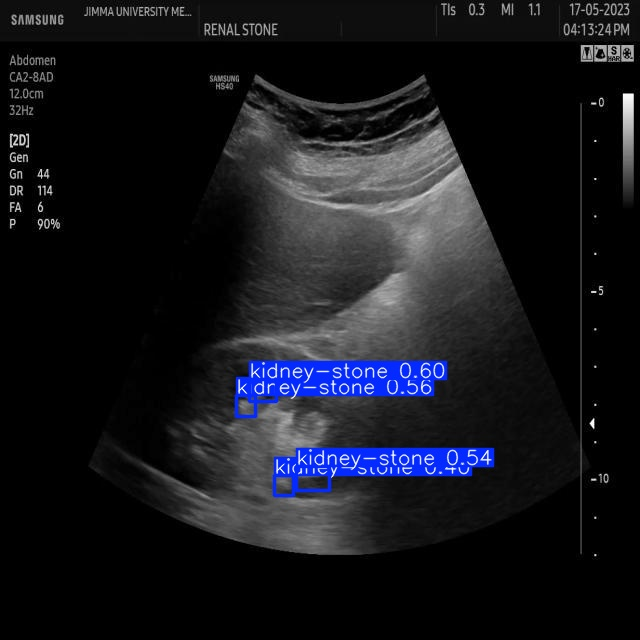

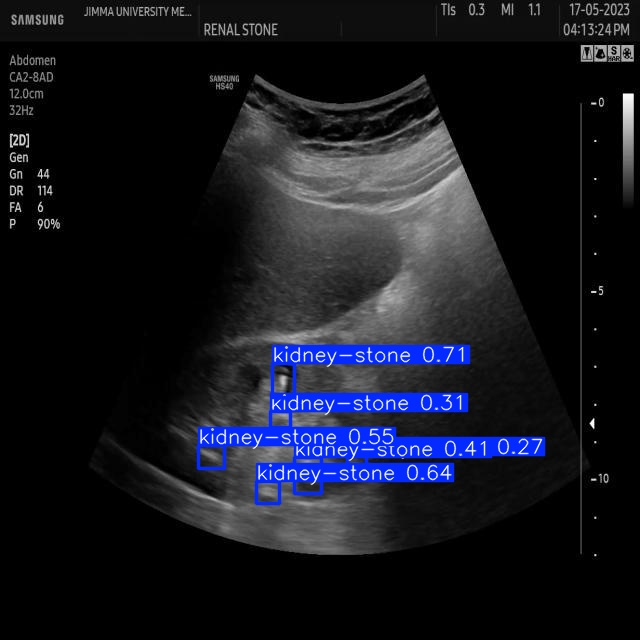

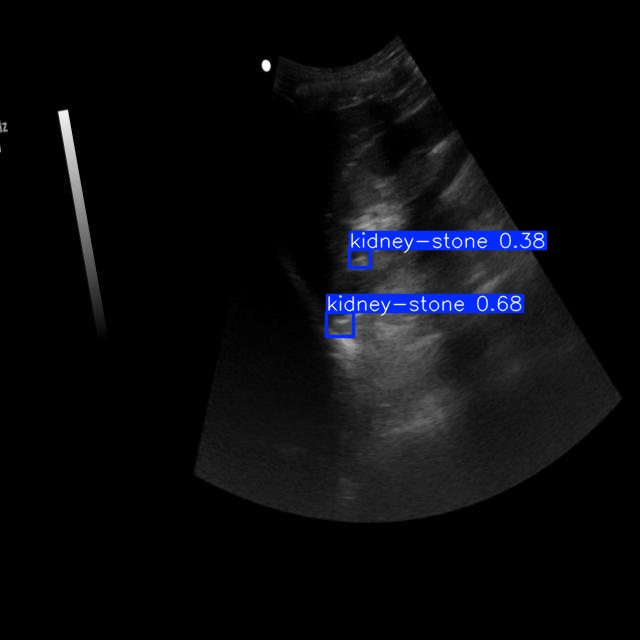

In [24]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [16]:
# draw custom confusion matrix with threshold 0.23
!yolo task=detect mode=val model=/content/drive/MyDrive/443_modeller/yolov11m/best.pt data={dataset.location}/data.yaml conf=0.23 save_conf=True save_json=True

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 303 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Scanning /content/kidney-stone-ultrasound-3/valid/labels.cache... 544 images, 6 backgrounds, 0 corrupt: 100% 544/544 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 1787. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 34/34 [00:16<00:00,  2.07it/s]
                   all        544       1787      0.775      0.781      0.795      0.474
          kidney-stone        317       1566      0.626      0.586      0.615      0.282
         normal kidney        221        221      0.923      0.977      0.974      0.666
Speed: 1.8ms preprocess, 22.8m

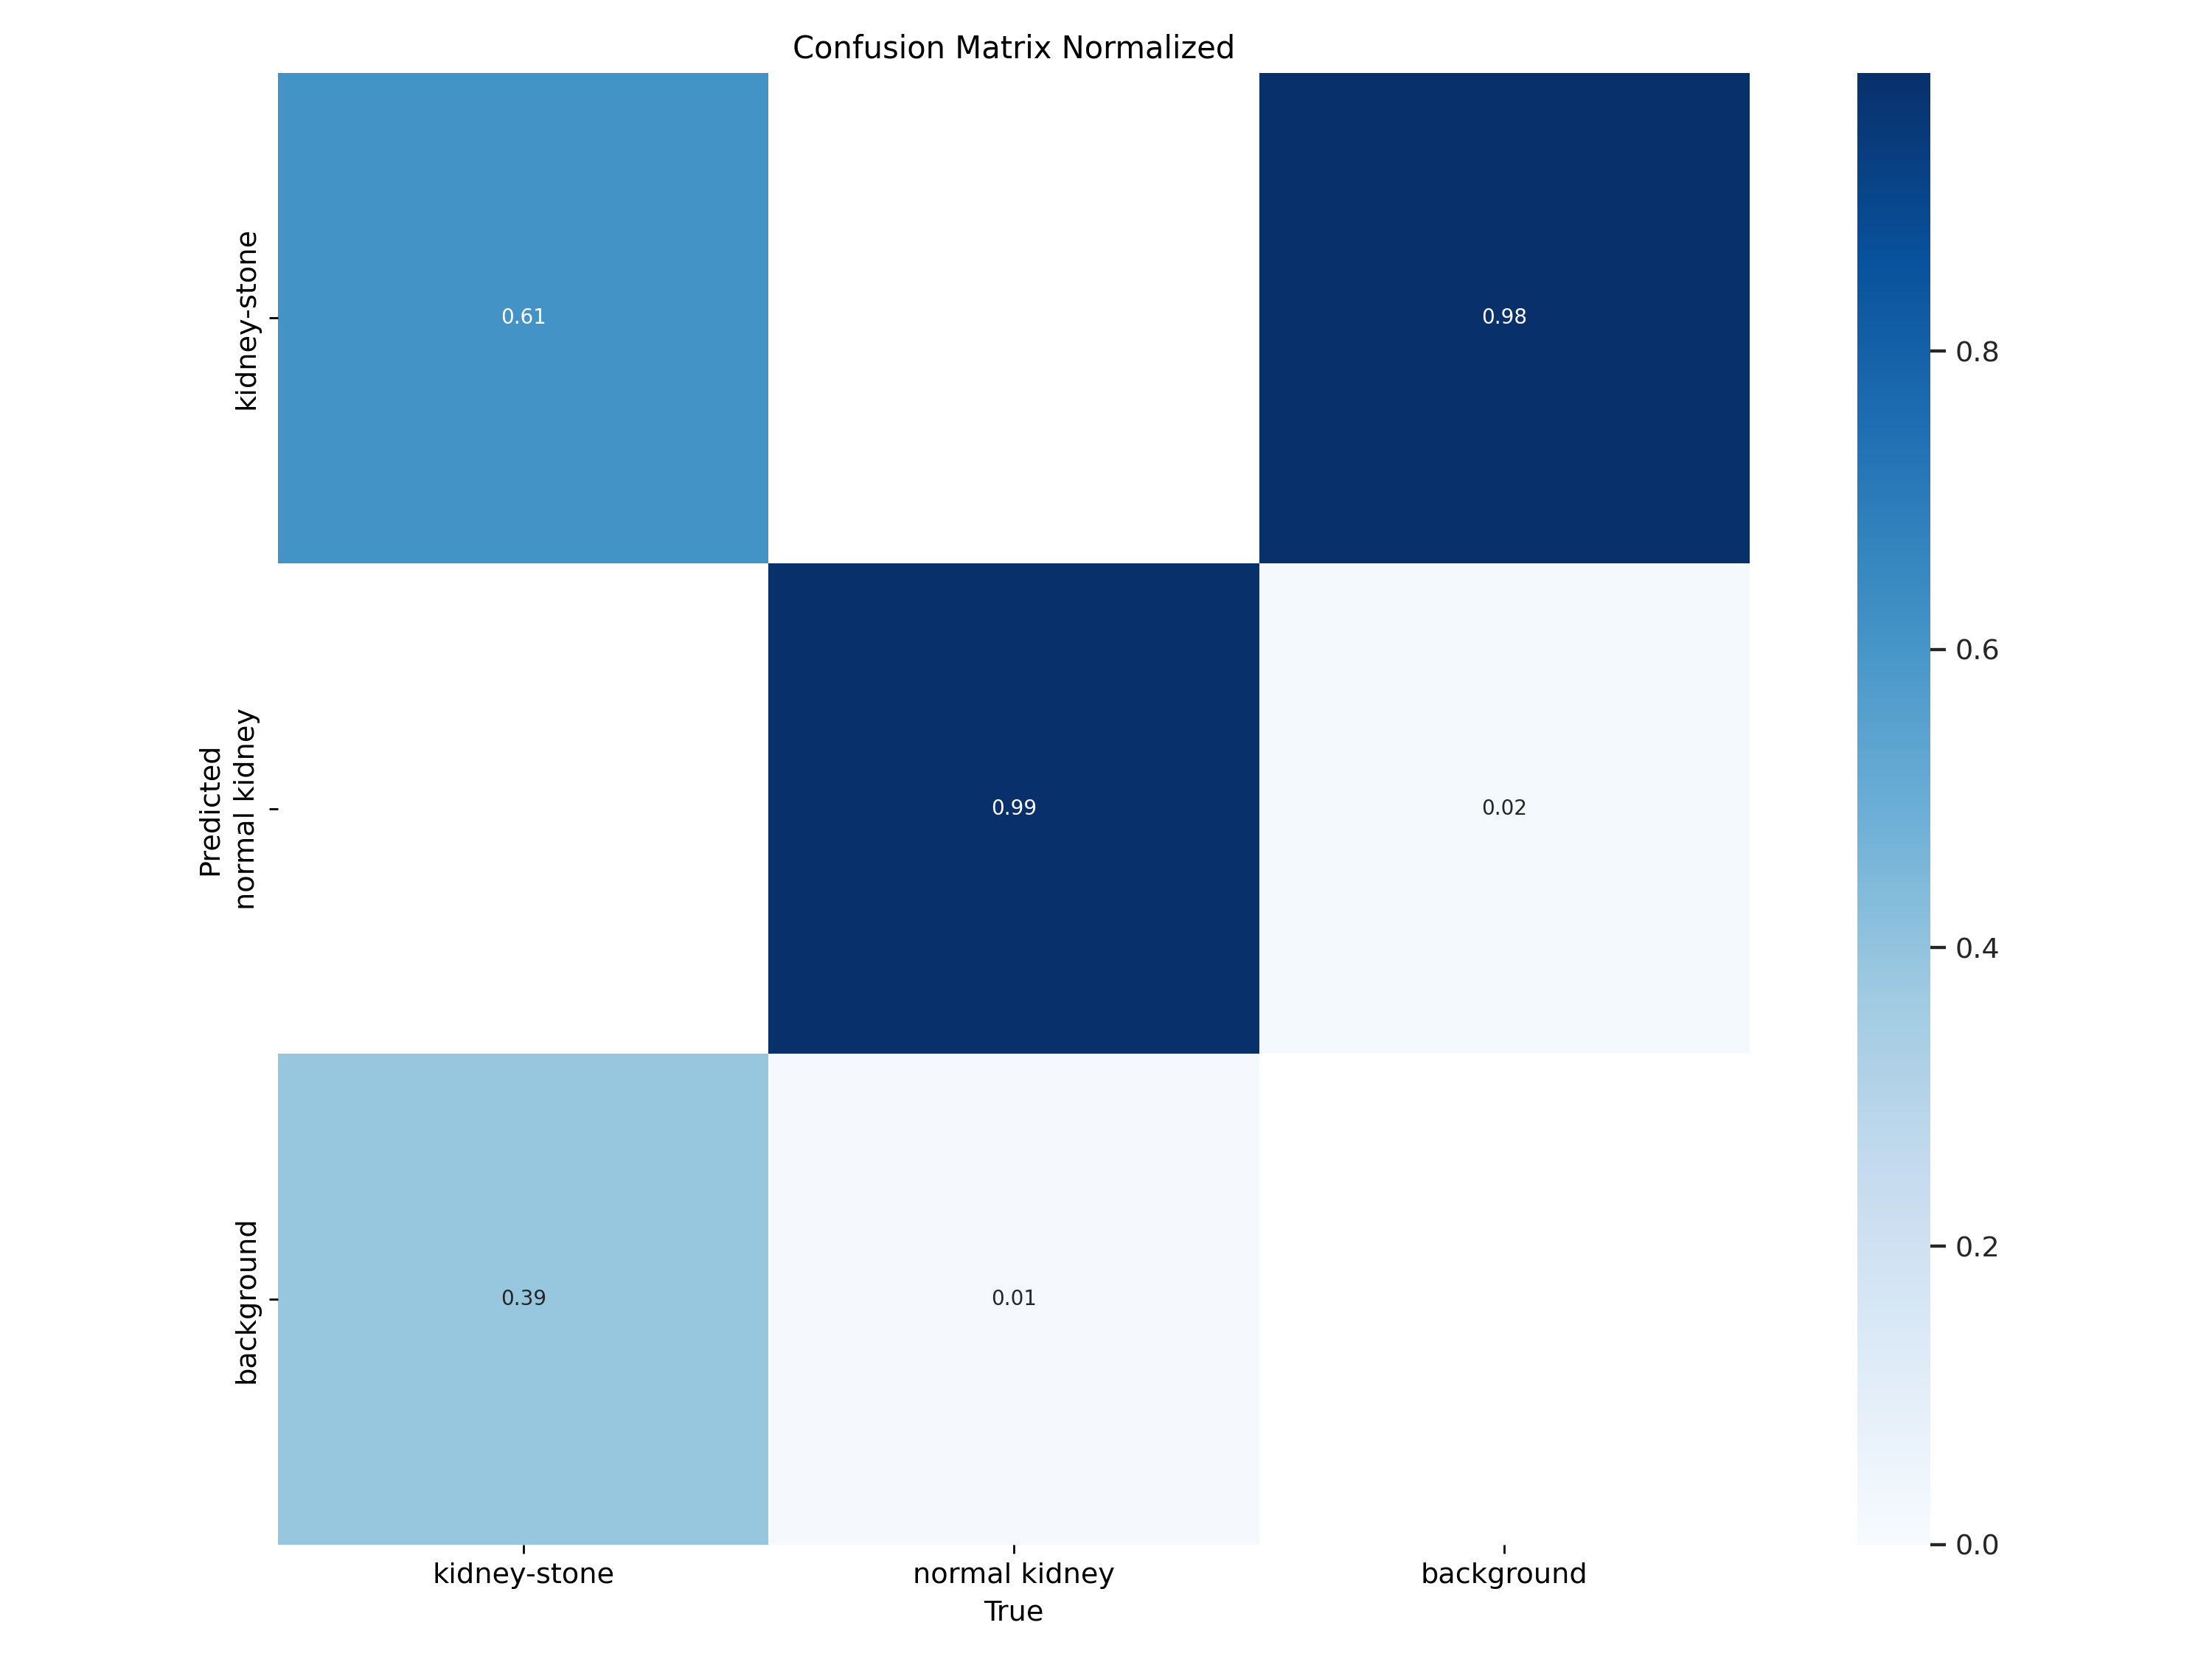

In [17]:

IPyImage(filename='/content/runs/detect/val4/confusion_matrix_normalized.png', width=1000)
